In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Load processed data
df = pd.read_csv('../data/processed/merged_clean.csv', parse_dates=['Date'])

print("✅ Data loaded:", df.shape)
print(df.head())

✅ Data loaded: (420285, 21)
   Store  Dept       Date  Weekly_Sales  IsHoliday Type    Size  Temperature  \
0      1     1 2010-02-05      24924.50      False    A  151315        42.31   
1      1     1 2010-02-12      46039.49       True    A  151315        38.51   
2      1     1 2010-02-19      41595.55      False    A  151315        39.93   
3      1     1 2010-02-26      19403.54      False    A  151315        46.63   
4      1     1 2010-03-05      21827.90      False    A  151315        46.50   

   Fuel_Price  MarkDown1  ...  MarkDown3  MarkDown4  MarkDown5         CPI  \
0       2.572        0.0  ...        0.0        0.0        0.0  211.096358   
1       2.548        0.0  ...        0.0        0.0        0.0  211.242170   
2       2.514        0.0  ...        0.0        0.0        0.0  211.289143   
3       2.561        0.0  ...        0.0        0.0        0.0  211.319643   
4       2.625        0.0  ...        0.0        0.0        0.0  211.350143   

   Unemployment  Year 

Times Series Length: 143
Date Range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


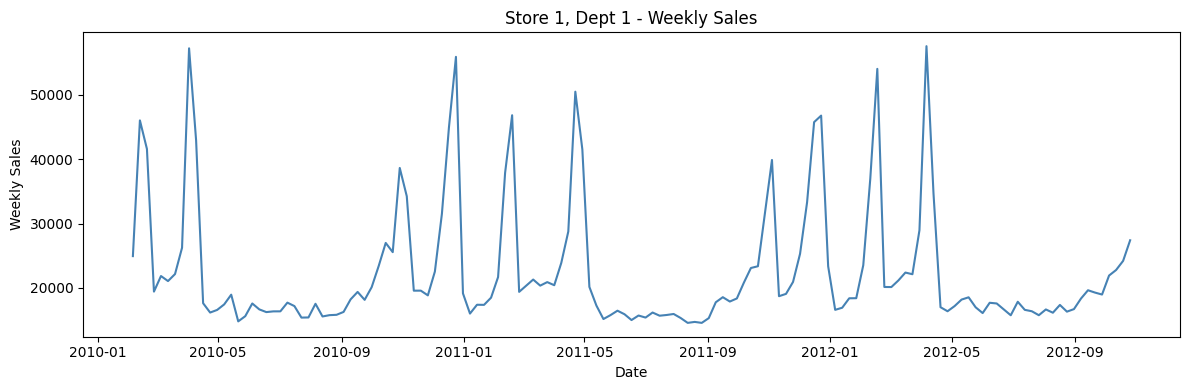

In [3]:
#preparing a single time series for ARIMA, one store and one department at a time.
store_id = 1
dept_id = 1

ts= df[(df['Store'] == store_id) & (df['Dept'] == dept_id)].copy()
ts= ts.sort_values('Date').set_index('Date')
ts=ts['Weekly_Sales']

print(f"Times Series Length: {len(ts)}")
print(f"Date Range: {ts.index.min()} to {ts.index.max()}")

#plot it
plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values, color='steelblue')
plt.title('Store 1, Dept 1 - Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

Train size: 131 weeks
Test size: 12 weeks


C:\Users\91951\anaconda3\envs\retailsense\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\91951\anaconda3\envs\retailsense\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\91951\anaconda3\envs\retailsense\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)



 ARIMA MAE: $3,022.90


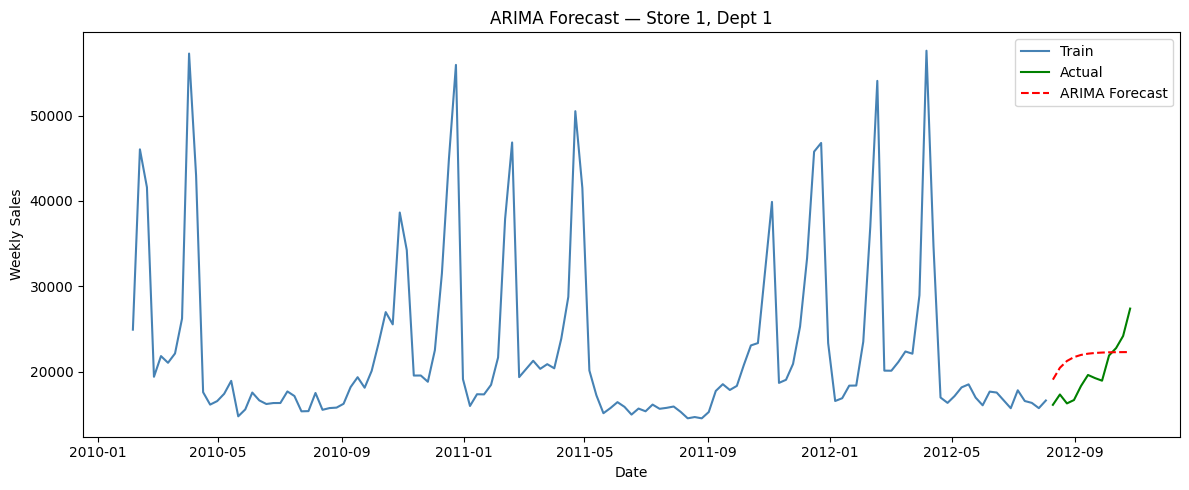

In [4]:
 #split data into train and test sets
train_size = len(ts) - 12
train_ts= ts.iloc[:train_size]
test_ts= ts.iloc[train_size:]

print(f"Train size: {len(train_ts)} weeks")
print(f"Test size: {len(test_ts)} weeks")

#Fit ARIMA Model (p=1, d=1, q=1) - standard starting point
model = ARIMA(train_ts, order=(1,1,1))
fitted= model.fit()

#forecast
forecast=fitted.forecast(steps=12)

#calculate MAE
mae= mean_absolute_error(test_ts, forecast)
print(f"\n ARIMA MAE: ${mae:,.2f}")

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(train_ts.index, train_ts.values, label='Train', color='steelblue')
plt.plot(test_ts.index, test_ts.values, label='Actual', color='green')
plt.plot(test_ts.index, forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast — Store 1, Dept 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

MAE shows that on average the forecast is off by 3k per week. And the plot conveys that ARIMA is able to show an upward trend but the line goes flat, which tells us that it is missing the holiday trends. Lets try another model to see if it can perform better.

Importing plotly failed. Interactive plots will not work.
21:51:01 - cmdstanpy - INFO - Chain [1] start processing
21:51:02 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: $1,702.75
ARIMA MAE:   $3,022.90


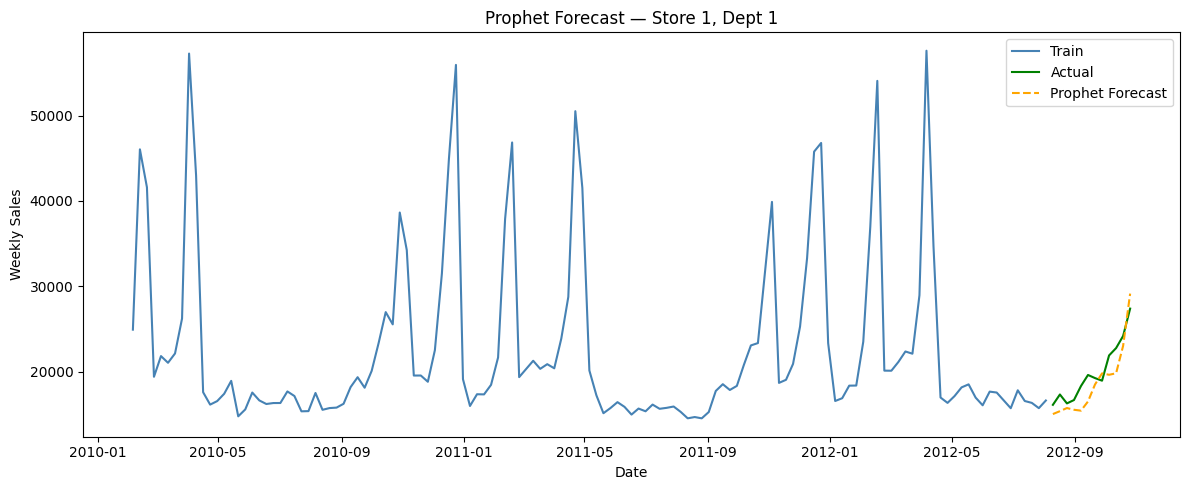

In [5]:
from prophet import Prophet

#Preophet requires columns named 'ds' and 'y'
prophet_df= ts.reset_index()
prophet_df.columns = ['ds','y']

#train test split
prophet_train= prophet_df.iloc[:train_size]
prophet_test= prophet_df.iloc[train_size:]

#fit model
m= Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)

#Forecast
future= m.make_future_dataframe(periods=12, freq='W')
forecast_prophet= m.predict(future)

# Get test predictions
prophet_preds = forecast_prophet.iloc[train_size:]['yhat'].values
mae_prophet = mean_absolute_error(prophet_test['y'].values, prophet_preds)
print(f"Prophet MAE: ${mae_prophet:,.2f}")
print(f"ARIMA MAE:   ${mae:,.2f}")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(prophet_train['ds'], prophet_train['y'], label='Train', color='steelblue')
plt.plot(prophet_test['ds'], prophet_test['y'], label='Actual', color='green')
plt.plot(prophet_test['ds'], prophet_preds, label='Prophet Forecast', color='orange', linestyle='--')
plt.title('Prophet Forecast — Store 1, Dept 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

we see a clear jump is model performance! Prophet is 44% better in forecasting the future trend compared to ARIMA.

CONS: This comparision is still limited to 1 store-1 department. Both models still miss the sudden spikes from external events like hurricanes, supply shocks, unexpected holidays etc..

In [6]:
# Results summary
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet'],
    'MAE': [mae, mae_prophet],
    'Store': [1, 1],
    'Dept': [1, 1]
})

print("=== Baseline Model Results ===")
print(results.to_string(index=False))
print(f"\nProphet improvement over ARIMA: {((mae - mae_prophet)/mae)*100:.1f}%")

=== Baseline Model Results ===
  Model         MAE  Store  Dept
  ARIMA 3022.900842      1     1
Prophet 1702.745793      1     1

Prophet improvement over ARIMA: 43.7%


Let's use LightGBM for better results and see how things go..

In [7]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

#filtering store 1 and dept 1 for a fare comparision
lgb_df = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
lgb_df = lgb_df.sort_values('Date').reset_index(drop=True)

# Features to use
feature_cols = ['Week', 'Month', 'Year', 'Quarter', 
                'IsHoliday', 'IsHolidaySeason',
                'Temperature', 'Fuel_Price', 
                'CPI', 'Unemployment',
                'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                'Size']

#converting IsHoliday to type int
lgb_df['IsHoliday'] = lgb_df['IsHoliday'].astype(int)

#train test split
train_lgb = lgb_df.iloc[:train_size]
test_lgb = lgb_df.iloc[train_size:] 

X_train = train_lgb[feature_cols]
y_train = train_lgb['Weekly_Sales']
X_test = test_lgb[feature_cols]
y_test = test_lgb['Weekly_Sales']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {feature_cols}")

Train: (131, 16), Test: (12, 16)
Features: ['Week', 'Month', 'Year', 'Quarter', 'IsHoliday', 'IsHolidaySeason', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Size']


--- Model Comparison : Store 1, Dept 1 ---
ARIMA Mae: $3,022.90
Prophet Mae: $1,702.75
LightGBM Mae: $2,970.14

LightGBM VS ARIMA improvement: 1.7%

LightGBM VS Prophet improvement: -74.4%


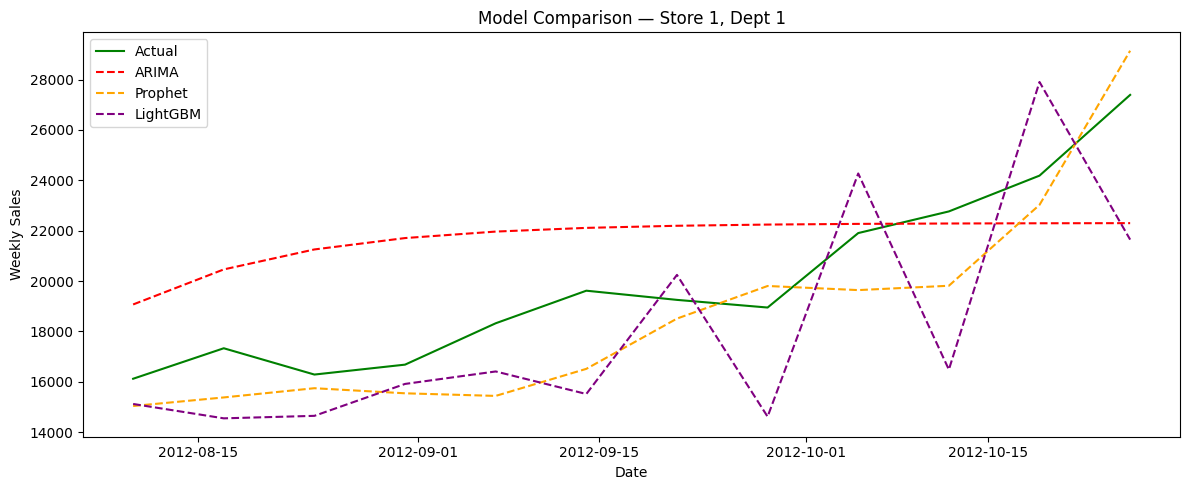

In [9]:
#trainig lightGBM
model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model_lgb.fit(X_train, y_train)

#predict
lgb_preds= model_lgb.predict(X_test)
mae_lgb= mean_absolute_error(y_test, lgb_preds)

print("--- Model Comparison : Store 1, Dept 1 ---")
print(f"ARIMA Mae: ${mae:,.2f}")
print(f"Prophet Mae: ${mae_prophet:,.2f}")
print(f"LightGBM Mae: ${mae_lgb:,.2f}")
print(f"\nLightGBM VS ARIMA improvement: {((mae - mae_lgb)/mae)*100:.1f}%")
print(f"\nLightGBM VS Prophet improvement: {((mae_prophet - mae_lgb)/mae_prophet)*100:.1f}%")

# Plot all three
plt.figure(figsize=(12, 5))
plt.plot(test_lgb['Date'], y_test.values, label='Actual', color='green')
plt.plot(test_ts.index, forecast, label='ARIMA', color='red', linestyle='--')
plt.plot(prophet_test['ds'], prophet_preds, label='Prophet', color='orange', linestyle='--')
plt.plot(test_lgb['Date'], lgb_preds, label='LightGBM', color='purple', linestyle='--')
plt.title('Model Comparison — Store 1, Dept 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

clearly Prophet is showing a better performance as compared to LightGBM, I think the data we fed to LightGBM is too low for it form patterns! let's make that fare but training LightGBM across all stores and departments as it shines with multivariates!!

In [11]:
# Training LightGBM on ALL stores and departments
full_df = df.copy()
full_df['IsHoliday'] = full_df['IsHoliday'].astype(int)
full_df = full_df.sort_values('Date').reset_index(drop=True)

# Using 2012-08 onwards as test (same period)
train_full = full_df[full_df['Date'] < '2012-08-01']
test_full = full_df[full_df['Date'] >= '2012-08-01']

feature_cols_full = ['Store', 'Dept', 'Week', 'Month', 'Year', 'Quarter',
                     'IsHoliday', 'IsHolidaySeason', 'Temperature', 
                     'Fuel_Price', 'CPI', 'Unemployment',
                     'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 
                     'MarkDown5', 'Size']

X_train_full = train_full[feature_cols_full]
y_train_full = train_full['Weekly_Sales']
X_test_full = test_full[feature_cols_full]
y_test_full = test_full['Weekly_Sales']

# Train
model_lgb_full = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
model_lgb_full.fit(X_train_full, y_train_full)

# Evaluate
lgb_preds_full = model_lgb_full.predict(X_test_full)
mae_lgb_full = mean_absolute_error(y_test_full, lgb_preds_full)
print(f"LightGBM (all stores) MAE: ${mae_lgb_full:,.2f}")
print(f"Prophet (Store 1 Dept 1) MAE: ${mae_prophet:,.2f}")
print(f"ARIMA (Store 1 Dept 1) MAE:  ${mae:,.2f}")

LightGBM (all stores) MAE: $3,180.90
Prophet (Store 1 Dept 1) MAE: $1,702.75
ARIMA (Store 1 Dept 1) MAE:  $3,022.90


It might seem like LightGBM is not performing as well as Prophet from the MAE values but frankly we can not compare them! Prophet is being scotred against 1 Store - 1 Dpt, while LightGBM is being scored again all!

In [14]:
# Fair comparison — LightGBM on Store 1, Dept 1 only
test_s1d1 = test_full[(test_full['Store'] == 1) & (test_full['Dept'] == 1)]
preds_s1d1 = model_lgb_full.predict(test_s1d1[feature_cols_full])
mae_lgb_s1d1 = mean_absolute_error(test_s1d1['Weekly_Sales'], preds_s1d1)

print("=== Fair Comparison — Store 1, Dept 1 ===")
print(f"ARIMA MAE:            ${mae:,.2f}")
print(f"Prophet MAE:          ${mae_prophet:,.2f}")
print(f"LightGBM MAE:         ${mae_lgb_s1d1:,.2f}")

=== Fair Comparison — Store 1, Dept 1 ===
ARIMA MAE:            $3,022.90
Prophet MAE:          $1,702.75
LightGBM MAE:         $1,854.67


Prophet wins on Store 1, Dept 1 : and that's completely fine and honest. Here's why this actually makes a great portfolio story:

Prophet wins on smooth, seasonal series like Dept 1 (steady, predictable)
LightGBM wins on complex, multi-feature series : departments with markdowns, volatile demand, cross-store patterns
In production you'd use both : Prophet for stable series, LightGBM for complex ones

All three models have one shortcoming in common! They all can not yet predict external influences such as a hurricane, sudden supply shock, unexpected competitor promotion etc.. 

To solve this we will be introducing LLM Agentic layer!!! ain't that exciting!! 

Structured data alone can not tell us that a hurricane is about to hit, however the news can! So the LLM Agent acts as a bridge between unstructured news and structured mdoel features.

We will be using 2 API calls here using (score_external_signals(date, category)):
1. Tavily: searches the web for news around a certain date and under a particular category - returns a list of headlines and snippets.
2. Groq/Llama3: Takes those new results and passes then onto Groq, with a prompt "Here are news headlines for this week. How much will this impact Walmart grocery sales? Give me a number between -0.5 and +0.5." LLM reads the news a returns a structured json doc.